In [1]:


# Tjis script is for plotting each commune's figures for the paper 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from statsmodels.tsa.seasonal import STL

from scipy import stats
from scipy import optimize
import seaborn as sns; sns.set() # set default plot styles

import statsmodels.api as sm

import time

from scipy.optimize import curve_fit

from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.preprocessing import StandardScaler 


import matplotlib.pyplot as plt
import seaborn as sns

!pip install cmcrameri

import cmcrameri.cm as cmc

In [7]:
file = '/Users/alex/Dropbox/MIRA_Madagascar_Project/Final_Scripts/mira_cleaned_git.csv'

mira = pd.read_csv(file, delimiter = ',')

In [8]:
print(mira.head)

# ========= Select Commune Number ========================
select_commune = mira[mira['commune'] == 1]
commune_num = select_commune['commune'].iloc[0]

# Select just important foods

select_foods = ['month', 'year', 'Maize', 'Sorghum', 'Rice', 'Cassava Root',
                'Sweet Potato', 'red cactus', 'peas']
important_foods = select_commune[select_foods]

important_foods

<bound method NDFrame.head of         ID    year  month   day  Maize  Sorghum  Millet  Rice  Cassava Root  \
0        1  2018.0    8.0   1.0    0.0      0.0     0.0   0.0           0.0   
1        1  2018.0    9.0  22.0    1.0      0.0     0.0   0.0           1.0   
2        1  2018.0   10.0   1.0    1.0      0.0     0.0   0.0           0.0   
3        1  2018.0   11.0   9.0    1.0      0.0     0.0   0.0           0.0   
4        1  2018.0   12.0  21.0    0.0      1.0     0.0   0.0           0.0   
...    ...     ...    ...   ...    ...      ...     ...   ...           ...   
22929  547  2021.0   10.0  18.0    1.0      0.0     0.0   0.0           0.0   
22930  547  2021.0   11.0  17.0    0.0      0.0     0.0   0.0           0.0   
22931  547  2021.0   12.0   6.0    0.0      0.0     0.0   0.0           0.0   
22932  547  2022.0    1.0  18.0    0.0      0.0     0.0   0.0           0.0   
22933  547  2022.0    2.0  15.0    0.0      0.0     0.0   0.0           0.0   

       Cassava Leaves

,month,year,Maize,Sorghum,Rice,Cassava Root,Sweet Potato,red cactus,peas
0,8.0,2018.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,9.0,2018.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
2,10.0,2018.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,11.0,2018.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,12.0,2018.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...
6085,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6086,11.0,2021.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
6087,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6088,1.0,2022.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


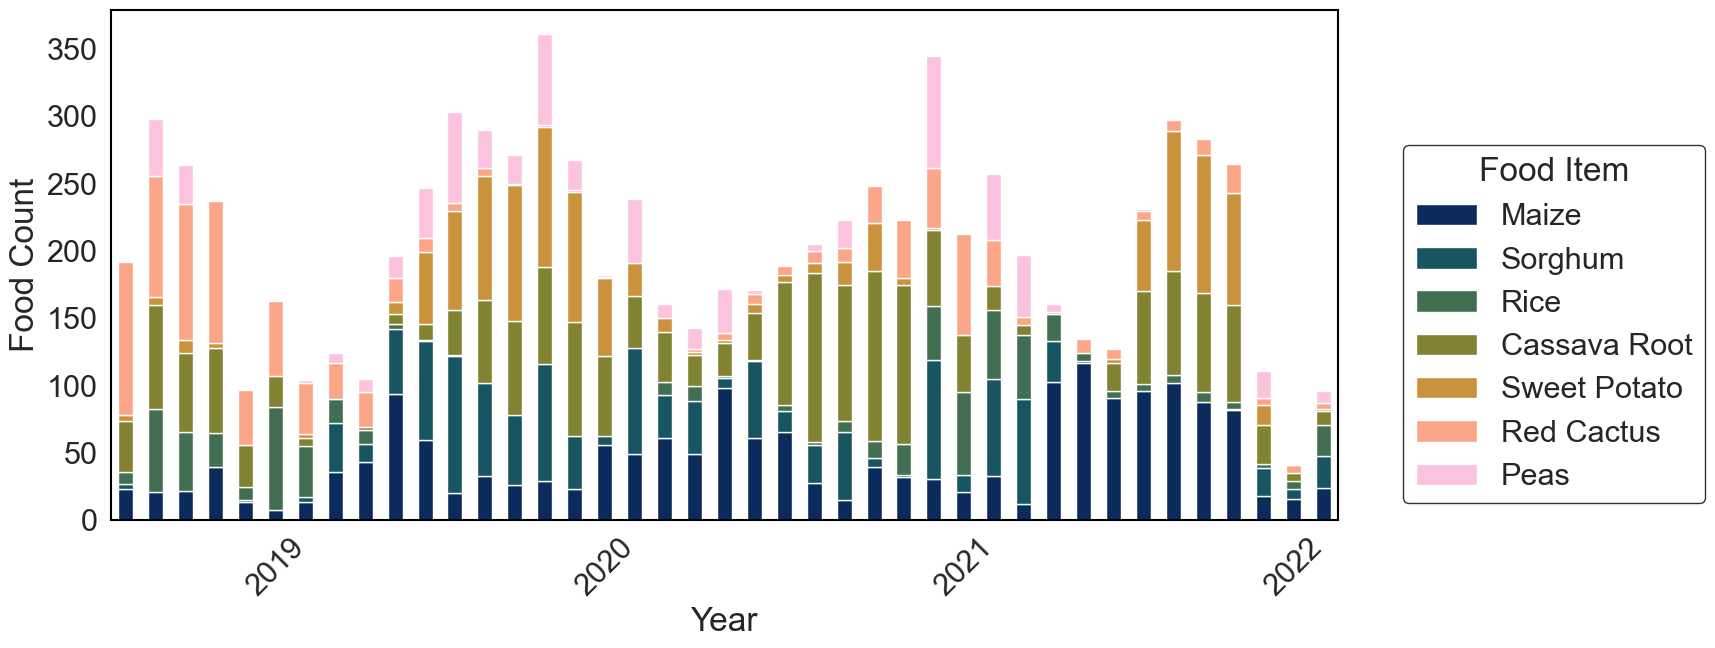

In [9]:
#ensure month and year are integers
# important_foods['year'] = important_foods['year'].astype(int)
# important_foods['month'] = important_foods['month'].astype(int)

# Group and prepare YearMonth index
grouped = important_foods.groupby(['year', 'month'], as_index=False).sum(numeric_only=True)
grouped['YearMonth'] = pd.to_datetime(
    dict(year=grouped['year'], month=grouped['month'], day=1), errors='coerce'
)
grouped = grouped.dropna(subset=['YearMonth']).set_index('YearMonth')


# Define food columns and color map
food_cols = ['Maize', 'Sorghum', 'Rice', 'Cassava Root', 'Sweet Potato', 'red cactus', 'peas']

food_colors = dict(zip(food_cols, cmc.batlow(np.linspace(0.05, 0.95, len(food_cols)))))

# food_colors = {
#     'Maize': '#FFD700',
#     'Sorghum': '#D2B48C',
#     'Rice': '#F5F5DC',
#     'Cassava Root': '#562014',
#     'Sweet Potato': '#f77909',
#     'red cactus': '#DC143C',
#     'peas': '#228B22'
# }


# Plot
sns.set_context("notebook", font_scale=2.0)
fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')

grouped[food_cols].plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=[food_colors[col] for col in food_cols],
    legend=False
)

# Labeling and aesthetic cleanup
ax.set_xlabel('Year')
ax.set_ylabel('Food Count')
ax.set_title('')
ax.grid(False)
ax.set_facecolor('white')
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

# Legend formatting
handles, labels = ax.get_legend_handles_labels()
labels = [label.title() for label in labels]
legend = fig.legend(handles, labels, title='Food Item', loc='center left', bbox_to_anchor=(1.01, 0.5))
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('black')

# Set x-ticks to only show January of each year
jan_locs = [i for i, dt in enumerate(grouped.index) if dt.month == 1]
jan_labels = [str(dt.year) for dt in grouped.index[jan_locs]]

ax.set_xticks(jan_locs)
ax.set_xticklabels(jan_labels, rotation=45, ha='center')

plt.tight_layout()
plt.show()



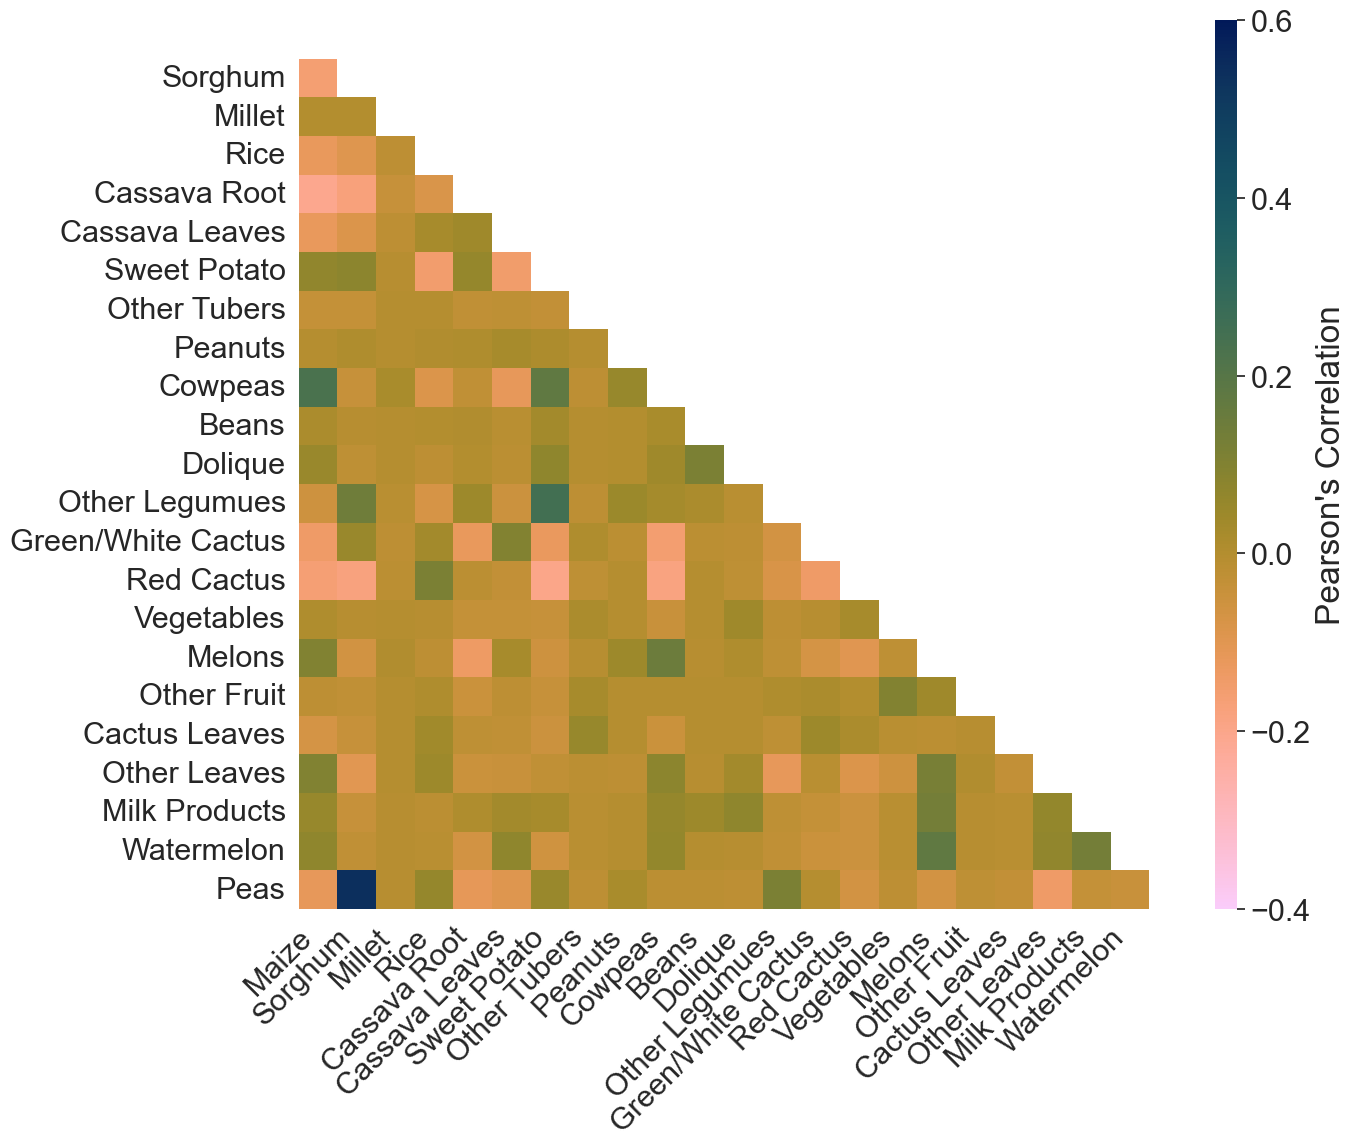

In [10]:
import matplotlib.gridspec as gridspec

sns.set_context("notebook", font_scale=2.0)


# Selected foods
food_cols = ['Maize', 'Sorghum', 'Millet', 'Rice', 'Cassava Root', 'Cassava Leaves', 
             'Sweet Potato', 'Other Tubers', 'Peanuts', 'Cowpeas', 'Beans', 'Dolique', 
             'Other Legumues', 'green/white cactus', 'red cactus', 'vegetables', 
             'melons', 'other fruit', 'cactus leaves', 'other leaves', 
             'milk products', 'watermelon', 'peas']

# Ensure columns exist
food_cols = [col for col in food_cols if col in select_commune.columns]

# Compute correlation
corr_matrix = select_commune[food_cols].corr()

# Labels
xticks_custom = ["" if col.lower() == "peas" else col.title() for col in food_cols]
yticks_custom = ["" if col.lower() == "maize" else col.title() for col in food_cols]

# Mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Set up figure with tight colorbar
fig = plt.figure(figsize=(14, 12), facecolor='white')
gs = gridspec.GridSpec(1, 2, width_ratios=[40, 1])  # make colorbar narrow

# Axes
ax = fig.add_subplot(gs[0])
cbar_ax = fig.add_subplot(gs[1])

# Plot heatmap
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap= cmc.batlow_r,
    square=True,
    cbar_kws={'label': 'Pearson\'s Correlation'},
    cbar_ax=cbar_ax,
    linewidths=0,
    linecolor='gray',
    xticklabels=xticks_custom,
    yticklabels=yticks_custom,
    annot=False,
    vmin=-0.4,
    vmax=0.6,
    ax=ax
)

# Clean appearance
ax.set_facecolor('white')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.setp(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()


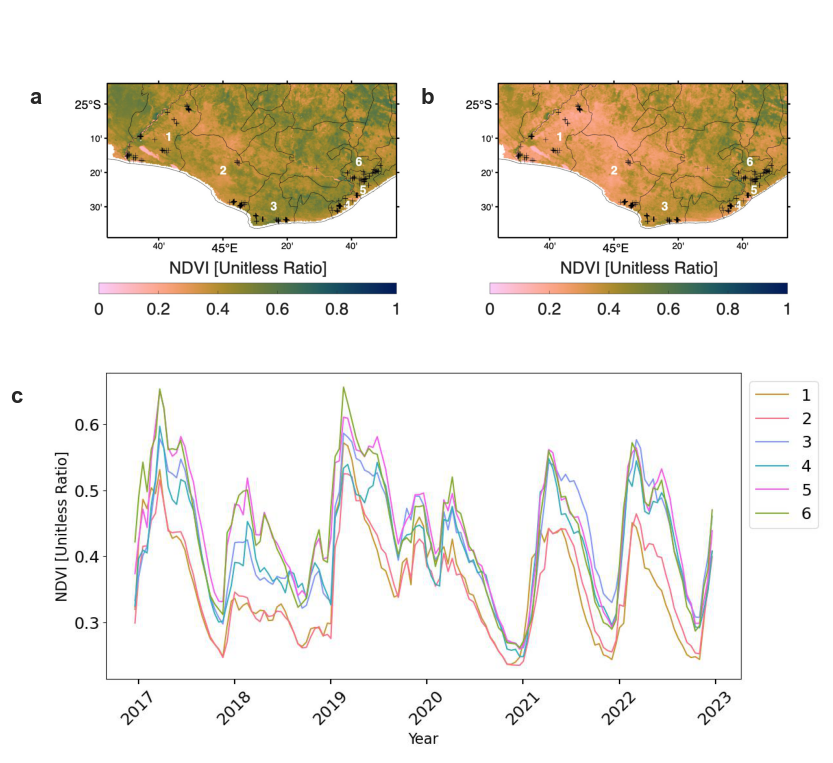

In [11]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.backends.backend_pdf import PdfPages

# Load image files
img1 = mpimg.imread('/Users/alex/Dropbox/MIRA_Madagascar_Project/smadagascar_pre_drought_bartlow.jpg')
img2 = mpimg.imread('/Users/alex/Dropbox/MIRA_Madagascar_Project/smadagascar_drought_2018_bartlow.jpg')
img3 = mpimg.imread('/Users/alex/Dropbox/MIRA_Madagascar_Project/ndvi_plot.jpg')

# Create a 2x2 grid layout: A & B on top row, C spanning bottom row
fig, axes = plt.subplots(2, 2, figsize=(10, 10), gridspec_kw={'height_ratios': [1, 1.2]})

# Image A (top-left)
axes[0, 0].imshow(img1)
axes[0, 0].axis('off')
axes[0, 0].text(-0.05, 0.75, 'a', transform=axes[0, 0].transAxes,
                fontsize=16, fontweight='bold', va='top')

# Image B (top-right)
axes[0, 1].imshow(img2)
axes[0, 1].axis('off')
axes[0, 1].text(-0.05, 0.75, 'b', transform=axes[0, 1].transAxes,
                fontsize=16, fontweight='bold', va='top')


# Merge bottom row to single axis for Image C
from matplotlib.gridspec import GridSpec
gs = axes[0, 0].get_gridspec()
for ax in axes[1]: ax.remove()  # Remove bottom row axes
axbig = fig.add_subplot(gs[1, :])  # Span bottom row

# Image C (bottom full-width)
axbig.imshow(img3)
axbig.axis('off')
axbig.text(-0.05, 0.95, 'c', transform=axbig.transAxes,
            fontsize=16, fontweight='bold', va='top')

# Minimize white space between images
plt.subplots_adjust(wspace=0.02, hspace=0.05)

# Save to PDF
with PdfPages("stitched_ndvi_figure.pdf") as pdf:
    pdf.savefig(fig, bbox_inches='tight')
